# OBS004 — The Local JWST Environment of ASPECS C19

## Scientific Objective

The goal of this investigation is to characterize the galaxy environment surrounding the ASPECS source **C19** using deep JWST NIRCam F200W imaging.

Building on the measurements completed in **OBS003**, this notebook expands the field of view around C19 in order to:

- identify nearby galaxies,
- locate neighboring ASPECS CO detections,
- investigate possible physical companions,
- search for evidence of interactions or galaxy group membership,
- compare the stellar environments of C19 and nearby CO-selected galaxies.

Particular attention will be given to **CO ID 1**, whose proximity to C19 suggests it may provide important insight into the local environment.

---

## Expected Products

- Large JWST cutouts surrounding C19
- Catalog of nearby galaxies
- Identification of CO counterparts
- Environmental measurements
- Publication-quality figures

In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

import astropy.units as u

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch
)

from astropy.table import Table

In [2]:
# ==========================================================
# Project Paths
# ==========================================================

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
CATALOGS = DATA / "catalogs"
IMAGERY = DATA / "imagery"

FIGURES = PROJECT / "figures" / "obs004"
DOCS = PROJECT / "docs" / "observations"

FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT}")
print(f"Figures : {FIGURES}")

Project : /home/glenn/Projects/CosmicIntelligenceLab
Figures : /home/glenn/Projects/CosmicIntelligenceLab/figures/obs004


In [3]:
# ==========================================================
# Target Information
# ==========================================================

c19 = SkyCoord(
    "03h32m38.53s",
    "-27d46m34.6s",
    frame="icrs"
)

print(c19)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.16054167, -27.77627778)>


# Phase 1 — Load the JWST F200W Mosaic

Load the calibrated JADES F200W mosaic that was identified and downloaded during OBS003.

This notebook begins with the existing science image rather than repeating the archive search performed previously.

In [4]:
# ==========================================================
# Phase 1
# Load JWST Science Image
# ==========================================================

jwst_file = (
    DATA
    / "raw"
    / "jwst"
    / "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

hdul = fits.open(jwst_file)

hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     280   ()      
  1  SCI           1 ImageHDU        75   (9884, 4386)   float32   
  2  ERR           1 ImageHDU        10   (9884, 4386)   float32   
  3  CON           1 ImageHDU        10   (9884, 4386, 2)   int32   
  4  WHT           1 ImageHDU         9   (9884, 4386)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (9884, 4386)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (9884, 4386)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (9884, 4386)   float32   
  8  HDRTAB        1 BinTableHDU    536   48R x 263C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 104A, 13A, 2A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 11A, 1A, 5A, D, D, D, D, D, D, D, D, 6A, 5A, 1A, 

In [5]:
# ==========================================================
# Phase 1
# Prepare Image and WCS
# ==========================================================

jwst_image = hdul["SCI"].data

jwst_wcs = WCS(
    hdul["SCI"].header
)

jwst_norm = ImageNormalize(
    jwst_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

print(jwst_image.shape)

Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(4386, 9884)


In [6]:
# ==========================================================
# Phase 2
# Create a Large JWST Cutout
# ==========================================================

large_size = (800, 800)

large_cutout = Cutout2D(
    data=jwst_image,
    position=c19,
    size=large_size,
    wcs=jwst_wcs
)

print("Cutout shape:", large_cutout.data.shape)

Cutout shape: (800, 800)


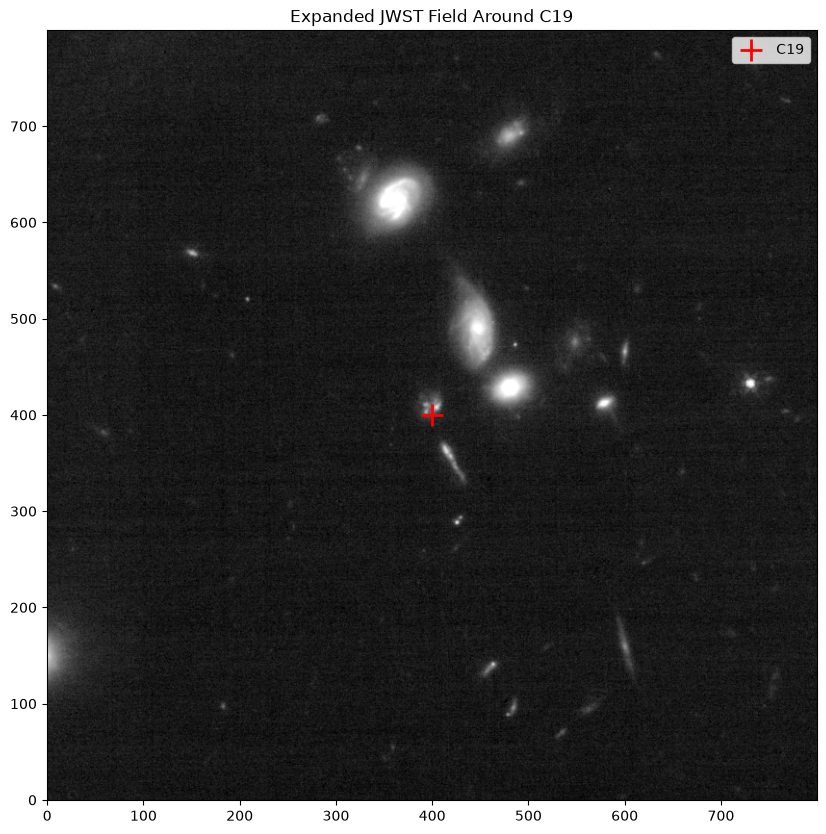

In [7]:
# ==========================================================
# Phase 2
# Display the Expanded JWST Field
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# C19 lies at the center of the cutout
ax.scatter(
    400,
    400,
    marker="+",
    s=250,
    color="red",
    linewidths=2,
    label="C19"
)

ax.set_title("Expanded JWST Field Around C19")

ax.legend()

plt.show()